# Fair Multi-class Classification Reproduce


## Import necessary library

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from scipy.optimize import minimize
from scipy.special import softmax

# Bổ sung theo Checklist
from lightgbm import LGBMClassifier
from fairlearn.reductions import ExponentiatedGradient, DemographicParity

# Cấu hình random seed
np.random.seed(777)

## Datasets

### Synthetic data

In [2]:
def make_unfair_classif(n=500, n_features=20, n_classes=6, n_clusters=10, p=0.75):
    centroids = np.random.uniform(-1, 1, (n_classes, n_features))
    
    for cl in range(n_classes):
        means = np.zeros((n_clusters, n_features))
        for comp in range(n_clusters):
            means[comp] = centroids[cl] + np.random.randn(n_features)
            
        weights = np.ones(n_clusters) / n_clusters
        mixture_idx = np.random.choice(n_clusters, size=n, replace=True, p=weights)
        
        M = np.zeros((len(mixture_idx), n_features))
        for i in range(n_clusters):
            M[mixture_idx == i] = np.random.multivariate_normal(means[i], np.eye(n_features), sum(mixture_idx == i))
        
        ym = cl * np.ones(len(mixture_idx))
        
        if cl == 0:
            M_all, y_all = M, ym
        else:
            M_all = np.concatenate((M_all, M), axis=0)
            y_all = np.concatenate((y_all, ym), axis=0)
    
    M_all = np.concatenate((M_all, -1 * np.ones((len(M_all), 1))), axis=1)
    
    for cl in np.arange(n_classes):
        index = (y_all == cl)
        n_index = np.sum(index)
        # Nửa class đầu thiên vị 1 kiểu, nửa sau thiên vị kiểu ngược lại
        prob = p if cl < n_classes // 2 else 1 - p
        M_all[index, -1] = 2 * np.random.binomial(1, prob, n_index) - 1
    
    shuffle_indexes = np.arange(len(y_all))
    np.random.shuffle(shuffle_indexes)
    return M_all[shuffle_indexes], y_all[shuffle_indexes]

def make_unfair_poolclassif(n, n_features, n_classes, n_clusters, n_pool=0, p=0.75):
    X, y = make_unfair_classif(n=n + n_pool, n_features=n_features, n_classes=n_classes, n_clusters=n_clusters, p=p)
    X_pool = X[:n_classes * n_pool] if n_pool > 0 else None
    X = X[n_classes * n_pool:]
    y = y[n_classes * n_pool:]
    return X, y, X_pool

### CRIME & DRUG Datasets

In [3]:
def split_60_20_20(X_scaled, y_categ, S):
    """
    Hàm tiện ích gộp biến nhạy cảm, xáo trộn và chia tỷ lệ đúng 60% Train, 20% Test, 20% Pool
    """
    X_full = np.concatenate((X_scaled, S.reshape(-1, 1)), axis=1)
    y_full = y_categ.astype(int)
    
    # Chia 20% Unlabeled (Pool) và 80% cho Train/Test
    X_train_test, X_pool, y_train_test, y_pool = train_test_split(
        X_full, y_full, test_size=0.20, random_state=777
    )
    
    # Từ 80% còn lại, chia 0.25 để Test chiếm đúng 20% tổng thể (0.8 * 0.25 = 0.20), Train chiếm 60% (0.8 * 0.75 = 0.60)
    X_train, X_test, y_train, y_test = train_test_split(
        X_train_test, y_train_test, test_size=0.25, random_state=777
    )
    
    return X_train, X_test, y_train, y_test, X_pool

def get_data_crime(K=5):
    """
    Dataset CRIME: Lớp mục tiêu phân chia bằng Quantile (K=5 hoặc K=2)
    """
    df = pd.read_csv('datasets/communites_and_crime.csv', header=None, na_values='?')
    df = df.drop(columns=[0, 1, 2, 3, 4])
    df = df.fillna(df.mean())
    y = df.iloc[:, -1].values
    
    sensitive_col_index = 8
    S_raw = df[sensitive_col_index].values
    S = np.where(S_raw >= np.median(S_raw), 1, -1)
    
    X = df.drop(columns=[sensitive_col_index, df.columns[-1]]).values
    X_scaled = MinMaxScaler().fit_transform(X)
    
    # Phân lớp dựa trên Quantile
    cuts = np.quantile(y, q=np.linspace(0, 1, num=K+1))
    y_categ = np.zeros(len(y))
    for cl in range(K):
        index = (y >= cuts[cl]) & (y <= cuts[cl+1])
        y_categ[index] = cl
        
    return split_60_20_20(X_scaled, y_categ, S)


def get_data_drug(K=4):
    """
    Dataset DRUG: Lớp mục tiêu phân chia bằng Nhóm ngữ nghĩa (K=4 hoặc K=2)
    """
    df = pd.read_csv("datasets/drug_consumption.csv") 
    y_raw = df['Cannabis'].str.replace('CL', '').astype(int).values
    
    # Biến nhạy cảm học vấn (College Degree) -> Trị số dương trong bộ dữ liệu chuẩn hóa của UCI tương đương có Degree.
    S = np.where(df['Education'] > 0, 1, -1) 
    
    drug_columns = [
        'Alcohol', 'Amphet', 'Amyl', 'Benzos', 'Caff', 'Cannabis', 'Choc', 
        'Coke', 'Crack', 'Ecstasy', 'Heroin', 'Ketamine', 'Legalh', 'LSD', 
        'Meth', 'Mushrooms', 'Nicotine', 'Semer', 'VSA'
    ]
    X = df.drop(columns=['ID'] + drug_columns).values
    X_scaled = MinMaxScaler().fit_transform(X)
    
    # Phân lớp dựa trên Ngữ nghĩa theo bài báo
    if K == 4:
        mapping = {0: 0, 1: 1, 2: 1, 3: 2, 4: 2, 5: 2, 6: 3}
    elif K == 2:
        mapping = {0: 0, 1: 0, 2: 0, 3: 1, 4: 1, 5: 1, 6: 1}
    else:
        raise ValueError("DRUG dataset chỉ hỗ trợ K=2 hoặc K=4 theo thực nghiệm gốc.")
        
    y_categ = np.array([mapping[val] for val in y_raw])
    
    return split_60_20_20(X_scaled, y_categ, S)

print("Data preparation functions are compliant with the paper's specs.")

Data preparation functions are compliant with the paper's specs.


## Algorithm implementation

In [4]:
import numpy as np
from scipy.optimize import minimize

def smooth_max(a, c=1e-5):
    """
    Hàm làm trơn soft-max (Mục 4.1 bài báo) thay thế cho hàm max(.) nhằm giúp hàm mục tiêu 
    có đạo hàm liên tục, thuận lợi cho thuật toán tối ưu SLSQP.
    Công thức: softmax(a) = sum(a_k * exp(a_k / c)) / sum(exp(a_k / c))
    """
    # Trừ đi max để tránh hiện tượng tràn số (overflow) khi tính exp
    a_max = np.max(a, axis=1, keepdims=True)
    exp_a = np.exp((a - a_max) / c)
    softmax_weights = exp_a / np.sum(exp_a, axis=1, keepdims=True)
    
    return np.sum(a * softmax_weights, axis=1)

def compute_beta(lam, unique_s):
    """
    Tính tham số beta_k,s dựa trên ma trận lambda cho các cặp (s, s').
    lam có kích thước (K, N_pairs)
    Trả về ma trận beta kích thước (K, N_S)
    """
    K = lam.shape[0]
    N_S = len(unique_s)
    beta = np.zeros((K, N_S))
    
    pair_idx = 0
    # Duyệt qua mọi cặp (s, s') với điều kiện s' > s theo đúng Định lý 5.1
    for i in range(N_S):
        for j in range(i + 1, N_S):
            # s = unique_s[i], s' = unique_s[j]
            # Cộng dồn cho s (vì s' > s)
            beta[:, i] += lam[:, pair_idx]
            # Trừ đi cho s' (vì s < s' hay khi xét góc nhìn của s' thì s < s')
            beta[:, j] -= lam[:, pair_idx]
            pair_idx += 1
            
    return beta

def lagrangian_objective(params, probas_pool, S_pool, epsilon, K, unique_s, c=1e-5):
    """
    Hàm mục tiêu H_hat cho bài toán Lagrangian đa lớp và đa thuộc tính nhạy cảm (Định lý 5.1).
    """
    N_S = len(unique_s)
    N_pairs = N_S * (N_S - 1) // 2
    
    # Chia mảng tham số phẳng 1D thành lam1 và lam2, sau đó reshape
    lam1_flat = params[: K * N_pairs]
    lam2_flat = params[K * N_pairs :]
    
    lam1 = lam1_flat.reshape(K, N_pairs)
    lam2 = lam2_flat.reshape(K, N_pairs)
    
    # Tính beta từ lambda
    beta1 = compute_beta(lam1, unique_s)
    beta2 = compute_beta(lam2, unique_s)
    
    cost = 0.0
    
    for idx_s, s in enumerate(unique_s):
        mask = (S_pool == s)
        if np.sum(mask) == 0:
            continue
            
        pi_s = np.sum(mask) / len(S_pool)
        p_k = probas_pool[mask] # shape: (N_samples_in_s, K)
        
        # Trích xuất vector beta cho riêng nhóm s hiện tại. Shape: (K,)
        b1_s = beta1[:, idx_s]
        b2_s = beta2[:, idx_s]
        
        # Tính điểm số a: pi_s * p_k - (beta1_s - beta2_s)
        # Broadcasting tự động căn lỉnh shape (N_samples_in_s, K) trừ đi (K,)
        a = pi_s * p_k - (b1_s - b2_s)
        
        max_vals = smooth_max(a, c)
        cost += np.mean(max_vals)
        
    # Penalty term: epsilon * tổng tất cả các lambda hiện có
    cost += epsilon * np.sum(params)
    
    return cost

def run_epsilon_fairness_post_processing(probas_test, probas_pool, S_test, S_pool, epsilon, c=1e-5):
    """
    Algorithm 1: Hậu xử lý mô hình bằng Demographic Parity.
    Đã được nâng cấp để hỗ trợ cả Binary và Multi-categorical sensitive attributes.
    """
    K = probas_pool.shape[1]
    
    # Trích xuất và sắp xếp các nhóm nhạy cảm
    unique_s = np.sort(np.unique(S_pool))
    N_S = len(unique_s)
    N_pairs = N_S * (N_S - 1) // 2
    
    # Thêm nhiễu ngẫu nhiên
    noise_pool = np.random.uniform(0, c, probas_pool.shape)
    noisy_probas_pool = probas_pool + noise_pool
    
    noise_test = np.random.uniform(0, c, probas_test.shape)
    noisy_probas_test = probas_test + noise_test
    
    # Tổng số tham số: lam1 và lam2, mỗi cái có K * N_pairs tham số
    num_params = 2 * K * N_pairs
    init_params = np.zeros(num_params)
    bounds = [(0.0, None)] * num_params
    
    # Giải bài toán tối ưu
    res = minimize(
        fun=lagrangian_objective,
        x0=init_params,
        args=(noisy_probas_pool, S_pool, epsilon, K, unique_s, c),
        method='SLSQP',
        bounds=bounds,
        options={'ftol': 1e-9, 'disp': False} 
    )
    
    # Trích xuất nghiệm tối ưu
    lam1_opt = res.x[: K * N_pairs].reshape(K, N_pairs)
    lam2_opt = res.x[K * N_pairs :].reshape(K, N_pairs)
    
    beta1_opt = compute_beta(lam1_opt, unique_s)
    beta2_opt = compute_beta(lam2_opt, unique_s)
    
    y_pred_fair = np.zeros(len(S_test), dtype=int)
    
    for idx_s, s in enumerate(unique_s):
        mask = (S_test == s)
        if np.sum(mask) == 0:
            continue
            
        pi_s = np.sum(S_pool == s) / len(S_pool)
        
        b1_s = beta1_opt[:, idx_s]
        b2_s = beta2_opt[:, idx_s]
        
        # Shift xác suất theo đúng định lý 5.1
        shifted_scores = pi_s * noisy_probas_test[mask] - (b1_s - b2_s)
        
        y_pred_fair[mask] = np.argmax(shifted_scores, axis=1)
        
    return y_pred_fair

## Experiment in binary case

In [5]:
from sklearn.preprocessing import MinMaxScaler
from lightgbm import LGBMClassifier
from fairlearn.reductions import ExponentiatedGradient, DemographicParity

import pandas as pd
import tensorflow.compat.v1 as tf
tf.disable_eager_execution() # AIF360 AdversarialDebiasing yêu cầu TF v1 graph execution

from aif360.datasets import BinaryLabelDataset
from aif360.algorithms.inprocessing import AdversarialDebiasing
from sklearn.neural_network import MLPClassifier

# Hàm tính toán độ bất công (Unfairness - Demographic Parity)
def calculate_unfairness(y_pred, S):
    """
    Tính Demographic Parity Unfairness cho Binary/Multi-class.
    Max chênh lệch xác suất dự đoán giữa các nhóm nhạy cảm.
    """
    classes = np.unique(y_pred)
    sensitive_groups = np.unique(S)
    max_diff = 0
    
    for c in classes:
        probs = []
        for s in sensitive_groups:
            # Tính P(g(X,S) = c | S = s)
            group_mask = (S == s)
            if np.sum(group_mask) > 0:
                prob = np.sum(y_pred[group_mask] == c) / np.sum(group_mask)
                probs.append(prob)
        
        # Max khác biệt giữa mọi cặp nhóm (Hỗ trợ cả đa thuộc tính |S| >= 2)
        if len(probs) >= 2:
            diff = np.max(probs) - np.min(probs)
            if diff > max_diff:
                max_diff = diff
                
    return max_diff

def convert_to_aif360_dataset(X, y, S):
    """
    Chuyển đổi numpy arrays sang BinaryLabelDataset của AIF360.
    Ánh xạ biến nhạy cảm S: -1 -> 0 (unprivileged), 1 -> 1 (privileged)
    """
    S_mapped = np.where(S == -1, 0, 1)
    
    df = pd.DataFrame(X)
    df['label'] = y
    df['sensitive_attr'] = S_mapped
    
    dataset = BinaryLabelDataset(
        df=df,
        label_names=['label'],
        protected_attribute_names=['sensitive_attr'],
        favorable_label=1,
        unfavorable_label=0
    )
    return dataset

def run_binary_experiments(X_train, X_test, y_train, y_test, X_pool, S_train, S_test, S_pool):
    epsilons = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
    
    # Cấu hình lưới tham số theo Mục 4.3.2 của paper
    rf_param_grid = {
        'n_estimators': np.arange(10, 201),
        'max_depth': np.arange(2, 17),
        'min_samples_split': np.arange(2, 11),
        'min_samples_leaf': np.arange(1, 9)
    }

    gbm_param_grid = {
        'reg_alpha': [0, 0.1, 1, 2, 5, 10, 20, 50],
        'reg_lambda': [0, 0.1, 1, 2, 5, 10, 20, 50],
        'n_estimators': np.arange(10, 201),
        'num_leaves': np.arange(6, 51),
        'max_depth': np.arange(2, 17),
        'min_child_samples': np.arange(10, 101)
    }

    print("\n[*] Đang Tuning siêu tham số cho Random Forest...")
    rf_search = RandomizedSearchCV(RandomForestClassifier(random_state=777), rf_param_grid, cv=3, n_iter=20, random_state=777, n_jobs=-1)
    rf_search.fit(X_train, y_train)
    best_rf = rf_search.best_estimator_ # <-- Chỉ lấy mô hình tốt nhất

    print("[*] Đang Tuning siêu tham số cho LightGBM...")
    gbm_search = RandomizedSearchCV(LGBMClassifier(random_state=777, verbose=-1), gbm_param_grid, cv=3, n_iter=20, random_state=777, n_jobs=-1)
    gbm_search.fit(X_train, y_train)
    best_gbm = gbm_search.best_estimator_ # <-- Chỉ lấy mô hình tốt nhất

    # Đưa các mô hình đã được cố định tham số vào dictionary
    models = {
        "reglog": LogisticRegression(random_state=777, max_iter=1000),
        "RF": best_rf,
        "GBM": best_gbm
    }
    
    results = []

    for model_name, model in models.items():
        print(f"\n[+] Đang chạy mô hình: {model_name}")
        
        # --- A. Train Unfair Model ---
        model.fit(X_train, y_train)
        y_pred_unfair = model.predict(X_test)
        
        acc_unfair = accuracy_score(y_test, y_pred_unfair)
        unf_unfair = calculate_unfairness(y_pred_unfair, S_test)
        results.append({'Model': model_name, 'Method': 'Unfair', 'Epsilon': 0.0, 'Accuracy': acc_unfair, 'Unfairness': unf_unfair})
        
        # --- B. Chạy Fair-learn (Benchmark) ---
        print(" -> Chạy Fair-learn benchmark...")
        for eps in epsilons:
            mitigator = ExponentiatedGradient(
                estimator=model, 
                constraints=DemographicParity(difference_bound=eps),
                max_iter=50
            )
            mitigator.fit(X_train, y_train, sensitive_features=S_train)
            y_pred_fl = mitigator.predict(X_test)
            
            acc_fl = accuracy_score(y_test, y_pred_fl)
            unf_fl = calculate_unfairness(y_pred_fl, S_test)
            results.append({'Model': model_name, 'Method': 'Fair-learn', 'Epsilon': eps, 'Accuracy': acc_fl, 'Unfairness': unf_fl})
            
        # --- C. Chạy Phương pháp đề xuất (Our Eps-Fair) ---
        print(" -> Chạy Epsilon-Fairness (Paper's Method)...")
        probas_test = model.predict_proba(X_test)
        probas_pool = model.predict_proba(X_pool)
        
        for eps in epsilons:
            y_pred_eps_fair = run_epsilon_fairness_post_processing(
                probas_test=probas_test, 
                probas_pool=probas_pool, 
                S_test=S_test, 
                S_pool=S_pool, 
                epsilon=eps
            )
            
            acc_eps_fair = accuracy_score(y_test, y_pred_eps_fair)
            unf_eps_fair = calculate_unfairness(y_pred_eps_fair, S_test)
            results.append({'Model': model_name, 'Method': 'Our Eps-Fair', 'Epsilon': eps, 'Accuracy': acc_eps_fair, 'Unfairness': unf_eps_fair})

    print("\n[+] Đang chạy mô hình: Neural Network (Đối chứng Adversarial)...")
    
    # Khởi tạo mô hình NN với tham số khớp với AIF360 Adversarial (Mục 4.3.3)
    nn_base = MLPClassifier(hidden_layer_sizes=(50,), batch_size=128, max_iter=200, random_state=777)
    
    # Train Unfair NN
    nn_base.fit(X_train, y_train)
    y_pred_nn_unfair = nn_base.predict(X_test)
    acc_nn_unfair = accuracy_score(y_test, y_pred_nn_unfair)
    unf_nn_unfair = calculate_unfairness(y_pred_nn_unfair, S_test)
    results.append({'Model': 'NN', 'Method': 'Unfair', 'Epsilon': 0.0, 'Accuracy': acc_nn_unfair, 'Unfairness': unf_nn_unfair})
    
    # Chạy Eps-Fair trên NN
    nn_probas_test = nn_base.predict_proba(X_test)
    nn_probas_pool = nn_base.predict_proba(X_pool)
    
    # Bài báo chạy eps-fair cho NN với các mức eps là {0.01, 0.1, 0.3, 0.5, 0.9} để so sánh
    nn_epsilons = [0.01, 0.1, 0.3, 0.5, 0.9] 
    for eps in nn_epsilons:
        y_pred_nn_eps = run_epsilon_fairness_post_processing(nn_probas_test, nn_probas_pool, S_test, S_pool, eps)
        acc_nn_eps = accuracy_score(y_test, y_pred_nn_eps)
        unf_nn_eps = calculate_unfairness(y_pred_nn_eps, S_test)
        results.append({'Model': 'NN', 'Method': 'Our Eps-Fair', 'Epsilon': eps, 'Accuracy': acc_nn_eps, 'Unfairness': unf_nn_eps})
    
    # --- D. Chạy Fair-adversarial (Benchmark) ---
    print(" -> Chạy AIF360 Fair-adversarial benchmark...")
    adv_tolerances = [0.01, 0.1, 0.5, 0.9, 1]
    
    dataset_train = convert_to_aif360_dataset(X_train, y_train, S_train)
    dataset_test = convert_to_aif360_dataset(X_test, y_test, S_test)
    
    privileged_groups = [{'sensitive_attr': 1}]
    unprivileged_groups = [{'sensitive_attr': 0}]
    
    for adv_weight in adv_tolerances:
        tf.reset_default_graph()
        sess = tf.Session()
        
        adv_model = AdversarialDebiasing(
            privileged_groups=privileged_groups,
            unprivileged_groups=unprivileged_groups,
            scope_name=f'adv_debiasing_{adv_weight}',
            debias=True,
            sess=sess,
            num_epochs=200,                  
            batch_size=128,                  
            classifier_num_hidden_units=50,  
            adversary_loss_weight=adv_weight 
        )
        adv_model.fit(dataset_train)
        dataset_pred = adv_model.predict(dataset_test)
        sess.close()
        
        y_pred_adv = dataset_pred.labels.flatten()
        acc_adv = accuracy_score(y_test, y_pred_adv)
        unf_adv = calculate_unfairness(y_pred_adv, S_test) 
        
        results.append({
            'Model': 'NN', 
            'Method': 'Fair-adversarial', 
            'Epsilon': adv_weight, 
            'Accuracy': acc_adv, 
            'Unfairness': unf_adv
        })

    return pd.DataFrame(results)

pip install 'aif360[inFairness]'


### Visualize output experiments functions

In [6]:
import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import seaborn as sns

def plot_figure_6(results_df, dataset_name="Dataset"):
    """
    Vẽ Hình 6: So sánh các mô hình truyền thống (Reglog, RF, GBM).
    Bao gồm: Unfair (điểm mốc), Fair-learn, và Our Eps-Fair.
    """
    df_fig6 = results_df[results_df['Model'].isin(['reglog', 'RF', 'GBM'])]
    
    # Tách dữ liệu: Unfair vẽ bằng điểm (scatter), các pp khác vẽ đường (line)
    df_lines = df_fig6[df_fig6['Method'] != 'Unfair']
    df_points = df_fig6[df_fig6['Method'] == 'Unfair']
    
    plt.figure(figsize=(10, 6))
    
    # Cấu hình bảng màu: Gán cứng 'Our Eps-Fair' màu đỏ, 'Fair-learn' màu xanh
    custom_palette = {'Fair-learn': 'blue', 'Our Eps-Fair': 'red'}
    
    # Vẽ đường cong cho Fair-learn và Our Eps-Fair với bảng màu tùy chỉnh
    ax = sns.lineplot(data=df_lines, x='Unfairness', y='Accuracy', hue='Method', 
                      style='Model', palette=custom_palette, markers=True, dashes=False)
    
    # Vẽ điểm tam giác lớn cho Unfair
    sns.scatterplot(data=df_points, x='Unfairness', y='Accuracy', style='Model', 
                    color='orange', s=250, markers=['^', '^', '^'], legend=False, zorder=5)
    
    # Lấy các chú thích hiện tại do lineplot tạo ra
    handles, labels = ax.get_legend_handles_labels()
    
    # Tạo một biểu tượng tam giác đại diện cho phương pháp Unfair
    unfair_marker = mlines.Line2D([], [], color='orange', marker='^', linestyle='None', 
                                  markersize=12, label='Unfair Baseline')
    
    # Gắn thêm chú thích Unfair vào danh sách
    handles.append(unfair_marker)
    labels.append('Unfair Baseline')
    
    plt.title(f"Hình 6: Phase Diagram - {dataset_name} (K=2)\n(Truyền thống vs Fair-learn vs Eps-Fair)")
    plt.xlabel(r"Unfairness $\hat{\mathcal{U}}$")
    plt.ylabel("Accuracy")
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # Truyền danh sách chú thích mới vào legend
    plt.legend(handles=handles, labels=labels, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

def plot_figure_7(results_df, dataset_name="Dataset"):
    """
    Vẽ Hình 7: So sánh chuyên biệt cho Neural Network.
    Bao gồm: Unfair NN (điểm mốc), Our Eps-Fair NN, và Fair-adversarial NN.
    """
    df_fig7 = results_df[results_df['Model'] == 'NN']
    
    # Tách dữ liệu
    df_lines = df_fig7[df_fig7['Method'] != 'Unfair']
    df_points = df_fig7[df_fig7['Method'] == 'Unfair']
    
    plt.figure(figsize=(8, 5))
    
    # Vẽ đường cong
    sns.lineplot(data=df_lines, x='Unfairness', y='Accuracy', hue='Method', markers=True, dashes=False, palette='Set1')
    
    # Vẽ điểm tam giác lớn cho Unfair NN
    sns.scatterplot(data=df_points, x='Unfairness', y='Accuracy', color='orange', 
                    s=300, marker='^', label='Unfair Baseline', zorder=5)
    
    plt.title(f"Hình 7: Phase Diagram - {dataset_name} (K=2)\n(Neural Network vs Fair-adversarial)")
    plt.xlabel(r"Unfairness $\hat{\mathcal{U}}$")
    plt.ylabel("Accuracy")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

### Run binary case

DRUG DATASET (K=2)

[*] Đang Tuning siêu tham số cho Random Forest...
[*] Đang Tuning siêu tham số cho LightGBM...

[+] Đang chạy mô hình: reglog
 -> Chạy Fair-learn benchmark...
 -> Chạy Epsilon-Fairness (Paper's Method)...

[+] Đang chạy mô hình: RF
 -> Chạy Fair-learn benchmark...
 -> Chạy Epsilon-Fairness (Paper's Method)...

[+] Đang chạy mô hình: GBM
 -> Chạy Fair-learn benchmark...
 -> Chạy Epsilon-Fairness (Paper's Method)...

[+] Đang chạy mô hình: Neural Network (Đối chứng Adversarial)...


c:\Users\ADMIN\OneDrive - VNU-HCMUS\Khai thác dữ liệu lớn\epsilon-fairness\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


 -> Chạy AIF360 Fair-adversarial benchmark...
Instructions for updating:
Please use `rate` instead of `keep_prob`. Rate should be set to `rate = 1 - keep_prob`.


Instructions for updating:
Please use `rate` instead of `keep_prob`. Rate should be set to `rate = 1 - keep_prob`.


epoch 0; iter: 0; batch classifier loss: 0.760126; batch adversarial loss: 0.702038
epoch 1; iter: 0; batch classifier loss: 0.683132; batch adversarial loss: 0.695218
epoch 2; iter: 0; batch classifier loss: 0.665483; batch adversarial loss: 0.717118
epoch 3; iter: 0; batch classifier loss: 0.647496; batch adversarial loss: 0.721705
epoch 4; iter: 0; batch classifier loss: 0.658189; batch adversarial loss: 0.683361
epoch 5; iter: 0; batch classifier loss: 0.616275; batch adversarial loss: 0.699103
epoch 6; iter: 0; batch classifier loss: 0.559590; batch adversarial loss: 0.737483
epoch 7; iter: 0; batch classifier loss: 0.580452; batch adversarial loss: 0.716995
epoch 8; iter: 0; batch classifier loss: 0.562299; batch adversarial loss: 0.702803
epoch 9; iter: 0; batch classifier loss: 0.575835; batch adversarial loss: 0.693328
epoch 10; iter: 0; batch classifier loss: 0.536626; batch adversarial loss: 0.704162
epoch 11; iter: 0; batch classifier loss: 0.523112; batch adversarial loss:

,Model,Method,Epsilon,Accuracy,Unfairness
0,reglog,Unfair,0.0,0.795756,0.293368
1,reglog,Fair-learn,0.0,0.755968,0.031389
2,reglog,Fair-learn,0.1,0.782493,0.170126
3,reglog,Fair-learn,0.2,0.795756,0.293368
4,reglog,Fair-learn,0.3,0.787798,0.182247
5,reglog,Fair-learn,0.4,0.787798,0.182247
6,reglog,Fair-learn,0.5,0.787798,0.182247
7,reglog,Our Eps-Fair,0.0,0.771883,0.004431
8,reglog,Our Eps-Fair,0.1,0.790451,0.088622
9,reglog,Our Eps-Fair,0.2,0.774536,0.146541


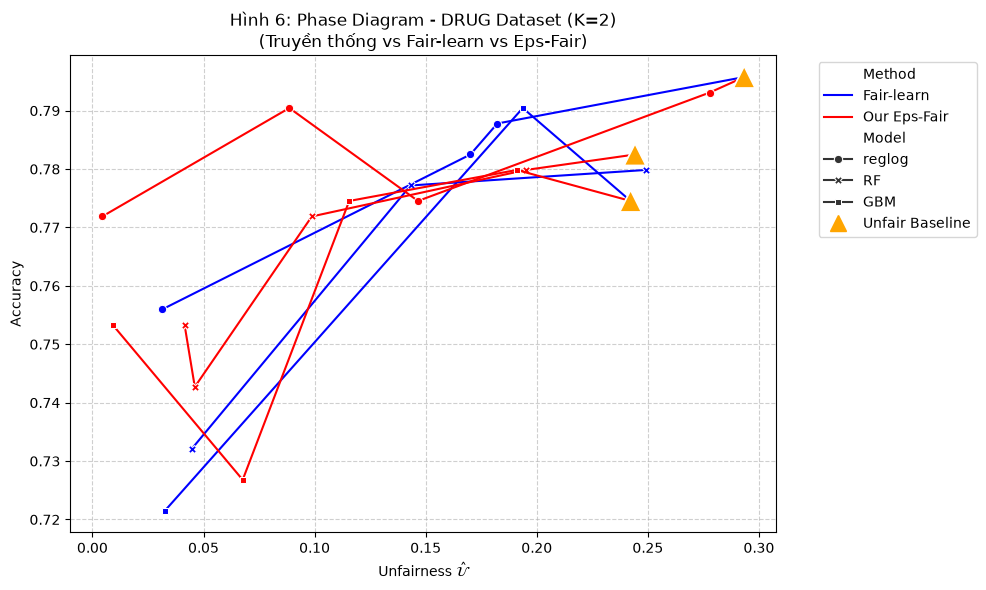

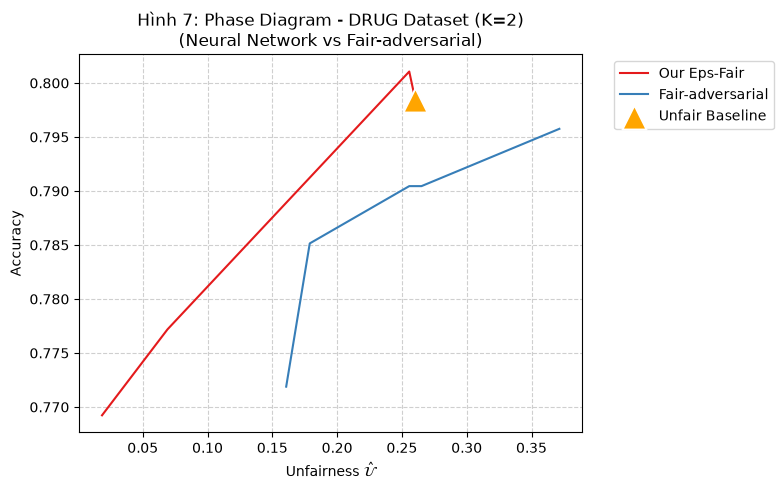

In [7]:
print("DRUG DATASET (K=2)")

# Gọi hàm lấy dữ liệu
X_train_full, X_test_full, y_train, y_test, X_pool_full = get_data_drug(K=2)

# Tách biến nhạy cảm S (cột cuối cùng) ra khỏi ma trận đặc trưng X
S_train = X_train_full[:, -1]
X_train = X_train_full[:, :-1]

S_test = X_test_full[:, -1]
X_test = X_test_full[:, :-1]

S_pool = X_pool_full[:, -1]
X_pool = X_pool_full[:, :-1]

# Tiến hành chạy các thuật toán
results_df = run_binary_experiments(X_train, X_test, y_train, y_test, X_pool, S_train, S_test, S_pool)

# Xem 10 kết quả đầu tiên
print("\n=== Results ===")
display(results_df.head(10))

plot_figure_6(results_df, dataset_name="DRUG Dataset")
plot_figure_7(results_df, dataset_name="DRUG Dataset")

CRIME DATASET (K=2)

[*] Đang Tuning siêu tham số cho Random Forest...
[*] Đang Tuning siêu tham số cho LightGBM...

[+] Đang chạy mô hình: reglog
 -> Chạy Fair-learn benchmark...
 -> Chạy Epsilon-Fairness (Paper's Method)...

[+] Đang chạy mô hình: RF
 -> Chạy Fair-learn benchmark...
 -> Chạy Epsilon-Fairness (Paper's Method)...

[+] Đang chạy mô hình: GBM
 -> Chạy Fair-learn benchmark...
 -> Chạy Epsilon-Fairness (Paper's Method)...

[+] Đang chạy mô hình: Neural Network (Đối chứng Adversarial)...
 -> Chạy AIF360 Fair-adversarial benchmark...
epoch 0; iter: 0; batch classifier loss: 0.794535; batch adversarial loss: 0.911458
epoch 1; iter: 0; batch classifier loss: 0.676029; batch adversarial loss: 0.747894
epoch 2; iter: 0; batch classifier loss: 0.678096; batch adversarial loss: 0.828771
epoch 3; iter: 0; batch classifier loss: 0.720341; batch adversarial loss: 0.867433
epoch 4; iter: 0; batch classifier loss: 0.722139; batch adversarial loss: 0.815706
epoch 5; iter: 0; batch class

,Model,Method,Epsilon,Accuracy,Unfairness
0,reglog,Unfair,0.0,0.832080,0.693350
1,reglog,Fair-learn,0.0,0.631579,0.058410
2,reglog,Fair-learn,0.1,0.721805,0.269529
3,reglog,Fair-learn,0.2,0.784461,0.495954
4,reglog,Fair-learn,0.3,0.817043,0.673118
5,reglog,Fair-learn,0.4,0.832080,0.693350
6,reglog,Fair-learn,0.5,0.832080,0.693350
7,reglog,Our Eps-Fair,0.0,0.644110,0.005278
8,reglog,Our Eps-Fair,0.1,0.661654,0.040640
9,reglog,Our Eps-Fair,0.2,0.696742,0.180155


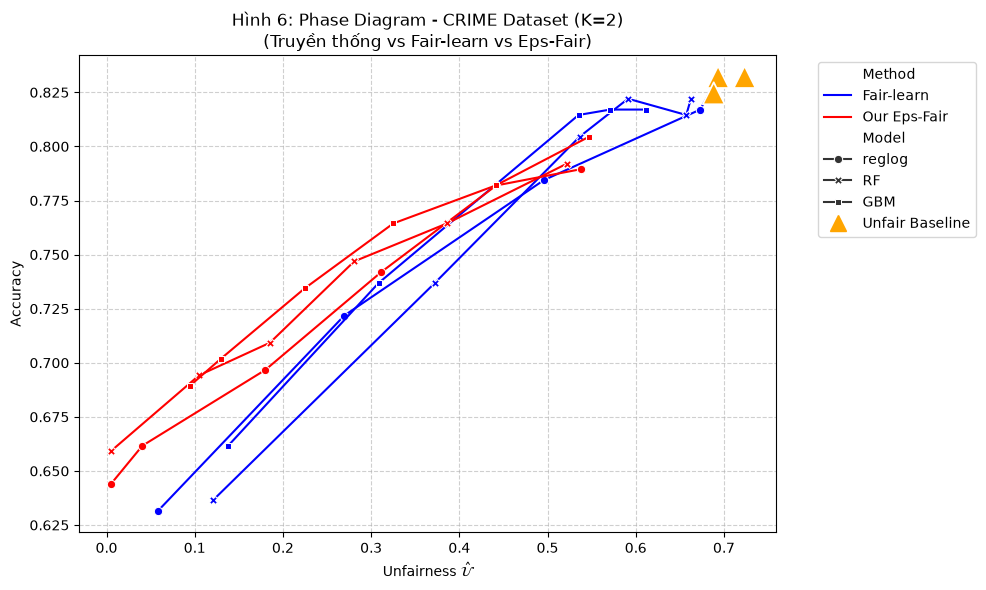

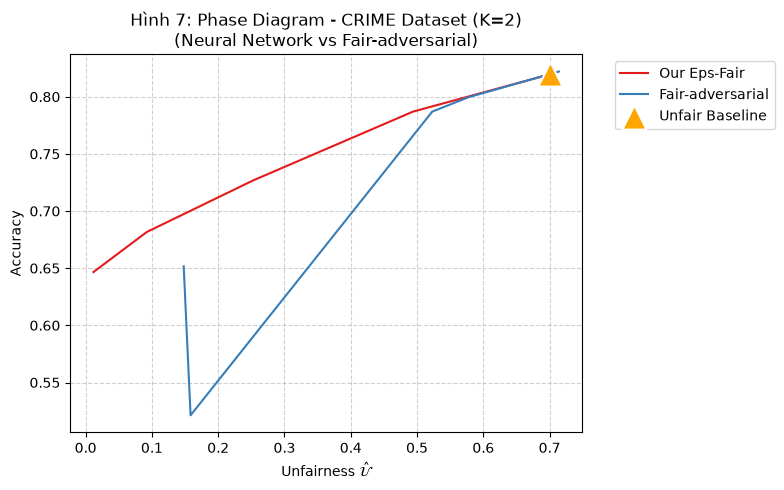

In [8]:
print("CRIME DATASET (K=2)")

# Gọi hàm lấy dữ liệu cho CRIME
X_train_full, X_test_full, y_train, y_test, X_pool_full = get_data_crime(K=2)

# Tách biến nhạy cảm S (cột cuối cùng) ra khỏi ma trận đặc trưng X
S_train = X_train_full[:, -1]
X_train = X_train_full[:, :-1]

S_test = X_test_full[:, -1]
X_test = X_test_full[:, :-1]

S_pool = X_pool_full[:, -1]
X_pool = X_pool_full[:, :-1]

# Tiến hành chạy các thuật toán
results_crime_df = run_binary_experiments(X_train, X_test, y_train, y_test, X_pool, S_train, S_test, S_pool)

# Xem 10 kết quả đầu tiên
print("\n=== Results ===")
display(results_crime_df.head(10))

plot_figure_6(results_crime_df, dataset_name="CRIME Dataset")
plot_figure_7(results_crime_df, dataset_name="CRIME Dataset")